In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import hist
from pandas.core.common import random_state

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Titanic-Dataset.csv", usecols = ['Age', 'Fare', 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [7]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


In [11]:
X_test

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0
...,...,...,...
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0


In [12]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [15]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([20.  ,  4.  , 26.  , 30.  , 35.  , 41.  ,  0.67, 15.  , 30.  ,
       45.  , 21.  , 26.  , 40.  , 17.  , 49.  , 19.  , 48.  , 14.  ,
       36.  , 17.  , 53.  , 16.  , 49.  , 17.  , 20.  , 44.  ,  9.  ,
       28.5 , 31.  , 54.  ,  2.  , 22.  , 30.  , 28.  , 36.  , 52.  ,
       28.  , 22.  , 47.  , 22.  , 29.  , 31.  , 20.  , 40.  , 26.  ,
        8.  , 18.  , 39.  , 28.  , 30.  , 27.  , 16.  , 47.  , 47.  ,
       16.  , 34.  , 43.  , 28.  , 39.  , 25.  , 28.  ,  6.  , 31.  ,
       18.  , 25.  , 24.  , 27.  , 50.  , 39.  , 20.  , 21.  , 21.  ,
       60.  , 13.  , 25.  ,  4.  , 19.  , 21.  , 36.  , 34.  , 22.  ,
       36.  ,  1.  , 19.  , 57.  , 23.  ,  2.  , 21.  , 38.  , 22.  ,
       19.  , 45.  , 18.  , 25.  , 43.  , 22.  , 36.  , 38.  , 30.5 ,
       42.  , 34.  , 14.5 , 34.  , 18.  , 42.  , 61.  , 36.5 , 35.  ,
       21.  , 32.5 , 22.  , 21.  , 50.  , 23.  , 31.  , 42.  , 11.  ,
       38.  , 25.  , 30.  , 13.  , 23.  , 62.  , 30.  , 32.  , 23.  ,
       19.  , 28.  ,

In [18]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values

In [19]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,23.5
493,71.0,49.5042,71.0
527,NaN,221.7792,25.0


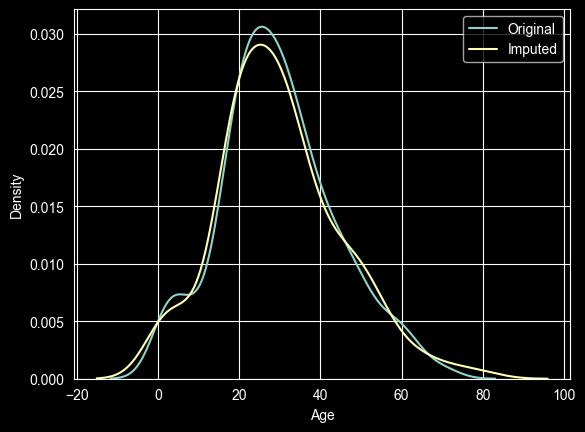

In [23]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_test['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [24]:
print("Original variable variance: ", X_train['Age'].var())
print("Imputed variable variance: ", X_test['Age_imputed'].var())

Original variable variance:  204.34951339046142
Imputed variable variance:  225.91213857259433


In [25]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,45.591406
Age,71.512440,204.349513,204.349513
Age_imputed,45.591406,204.349513,203.761724


<Axes: >

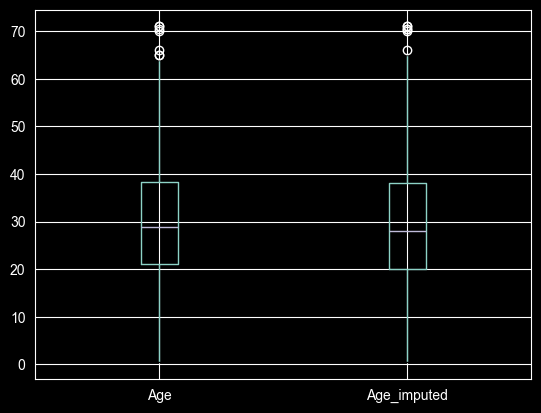

In [26]:
X_train[['Age', 'Age_imputed']].boxplot()

In [28]:
# if given is same the random value should be same
# sample_value = X_train['Age'].dropna().smaple(1, random_state = int(observation['Fare']))